Model for sentiment Analysis


In [25]:
import pandas as pd
import numpy as np
import re
import spacy
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import nltk
nltk.download('vader_lexicon')
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])
sia = SentimentIntensityAnalyzer()

[nltk_data] Downloading package vader_lexicon to C:\Users\akanksha
[nltk_data]     meshram\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [26]:
train_data = pd.read_csv('../data/processed/train_processed.csv')
print(train_data.head())

     id                                           Sentence Aspect Term  \
0  3121               But the staff was so horrible to us.       staff   
1  2777  To be completely fair, the only redeeming fact...        food   
2  1634  The food is uniformly exceptional, with a very...        food   
3  1634  The food is uniformly exceptional, with a very...     kitchen   
4  1634  The food is uniformly exceptional, with a very...        menu   

   polarity  from   to                                   cleaned_sentence  \
0  negative     8   13                but the staff was so horrible to us   
1  positive    57   61  to be completely fair the only redeeming facto...   
2  positive     4    8  the food is uniformly exceptional with a very ...   
3  positive    55   62  the food is uniformly exceptional with a very ...   
4   neutral   141  145  the food is uniformly exceptional with a very ...   

                                  processed_sentence aspect_category  
0                    

In [27]:
def get_sentiment(text):
    scores = sia.polarity_scores(str(text))
    compound = scores['compound']
    if compound >= 0.05:
        return 'positive'
    elif compound <= -0.05:
        return 'negative'
    else:
        return 'neutral'

In [28]:
train_data['predicted_sentiment'] = train_data['Sentence'].apply(get_sentiment)
print(train_data[['Sentence', 'Aspect Term', 'polarity', 'predicted_sentiment']].head(10))

                                            Sentence  \
0               But the staff was so horrible to us.   
1  To be completely fair, the only redeeming fact...   
2  The food is uniformly exceptional, with a very...   
3  The food is uniformly exceptional, with a very...   
4  The food is uniformly exceptional, with a very...   
5  Not only was the food outstanding, but the lit...   
6  Not only was the food outstanding, but the lit...   
7  Our agreed favorite is the orrechiete with sau...   
8  Our agreed favorite is the orrechiete with sau...   
9  Our agreed favorite is the orrechiete with sau...   

                           Aspect Term  polarity predicted_sentiment  
0                                staff  negative            negative  
1                                 food  positive            positive  
2                                 food  positive            positive  
3                              kitchen  positive            positive  
4                           

In [29]:
def analyze_review(review):
    
    aspect_keywords = {
        'Food'    : ['food', 'pizza', 'pasta', 'paneer', 'dish', 'meal',
                     'taste', 'chicken', 'fish', 'meat', 'dessert', 'bread',
                     'tikka', 'curry', 'rice', 'burger', 'sandwich', 'sauce',
                     'salad', 'soup', 'steak', 'seafood', 'cheese', 'egg',
                     'coffee', 'wine', 'beer', 'drinks', 'dessert', 'cake'],
        'Service' : ['waiter', 'waitress', 'staff', 'service', 'server',
                     'host', 'manager', 'chef', 'wait', 'slow', 'rude',
                     'attentive', 'friendly', 'reservation', 'delivery',
                     'forever', 'seated', 'helpful', 'crew', 'bartender'],
        'Ambience': ['ambience', 'ambiance', 'atmosphere', 'decor', 'music',
                     'vibe', 'environment', 'beautiful', 'cozy', 'romantic',
                     'loud', 'noisy', 'quiet', 'lighting', 'interior',
                     'comfortable', 'crowded', 'outdoor', 'indoor', 'view'],
        'Price'   : ['price', 'prices', 'cost', 'expensive', 'cheap', 'bill',
                     'value', 'money', 'overpriced', 'affordable', 'pricey',
                     'high', 'steep', 'worth', 'costly', 'tab', 'tips']
    }
    
    # Split into clauses by comma, 'but', 'however', 'although'
    clauses = re.split(r',\s*|\bbut\b|\bhowever\b|\balthough\b', review.lower())
    clauses = [c.strip() for c in clauses if c.strip()]
    
    # Further split each clause by 'and' to get granular aspect sentences
    final_clauses = []
    for clause in clauses:
        sub = re.split(r'\band\b', clause)
        final_clauses.extend([s.strip() for s in sub if s.strip()])
    
    # Match each aspect to its most relevant clause
    results = {}
    for aspect, keywords in aspect_keywords.items():
        for clause in final_clauses:
            if any(kw in clause for kw in keywords):
                score = sia.polarity_scores(clause)['compound']
                if score >= 0.05:
                    sentiment = 'positive'
                elif score <= -0.05:
                    sentiment = 'negative'
                else:
                    sentiment = 'neutral'
                results[aspect] = (sentiment, score)
                break
    
    # Print results cleanly
    print(f"\n📝 Review: {review}\n")
    print(f"{'Aspect':<15} {'Sentiment':<15} {'Score':<10}")
    print("─" * 42)
    for aspect, (sentiment, score) in results.items():
        emoji = '🟢' if sentiment == 'positive' else '🔴' if sentiment == 'negative' else '🟡'
        print(f"{emoji} {aspect:<13} {sentiment:<15} {score:.3f}")
    print()
    
    # Overall sentiment
    if results:
        avg_score = sum(score for _, score in results.values()) / len(results)
        overall = 'positive' if avg_score >= 0.05 else 'negative' if avg_score <= -0.05 else 'neutral'
        print(f"Overall Sentiment: {overall} (avg score: {avg_score:.3f})")

# Test it
analyze_review("Paneer tikka was delicious and the ambience was beautiful, but the waiter took forever and the prices are too high.")


📝 Review: Paneer tikka was delicious and the ambience was beautiful, but the waiter took forever and the prices are too high.

Aspect          Sentiment       Score     
──────────────────────────────────────────
🟢 Food          positive        0.572
🟡 Service       neutral         0.000
🟢 Ambience      positive        0.599
🟡 Price         neutral         0.000

Overall Sentiment: positive (avg score: 0.293)


In [30]:
# Filter out 'conflict' from polarity (VADER can't predict conflict)
eval_data = train_data[train_data['polarity'] != 'conflict'].copy()

# Compare predicted vs actual
from sklearn.metrics import classification_report
print(classification_report(
    eval_data['polarity'],
    eval_data['predicted_sentiment'],
    labels=['positive', 'negative', 'neutral']
))

              precision    recall  f1-score   support

    positive       0.75      0.82      0.79      2164
    negative       0.64      0.36      0.46       805
     neutral       0.33      0.42      0.37       633

    accuracy                           0.65      3602
   macro avg       0.57      0.53      0.54      3602
weighted avg       0.65      0.65      0.64      3602



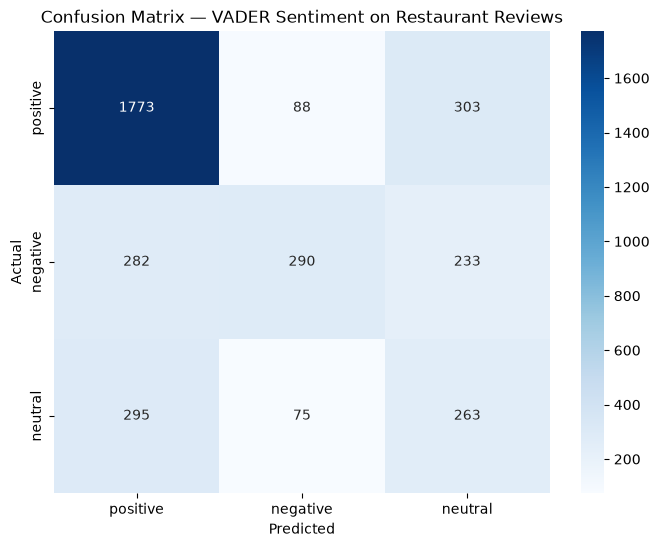

In [31]:
cm = confusion_matrix(
    eval_data['polarity'],
    eval_data['predicted_sentiment'],
    labels=['positive', 'negative', 'neutral']
)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['positive', 'negative', 'neutral'],
            yticklabels=['positive', 'negative', 'neutral'])
plt.title('Confusion Matrix — VADER Sentiment on Restaurant Reviews')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

predicted_sentiment  negative  neutral  positive
aspect_category                                 
ambience                   21       27       167
food                      246      474      1365
location                   15       12        60
others                     44      102       287
price                      32       78       155
service                   112      122       374


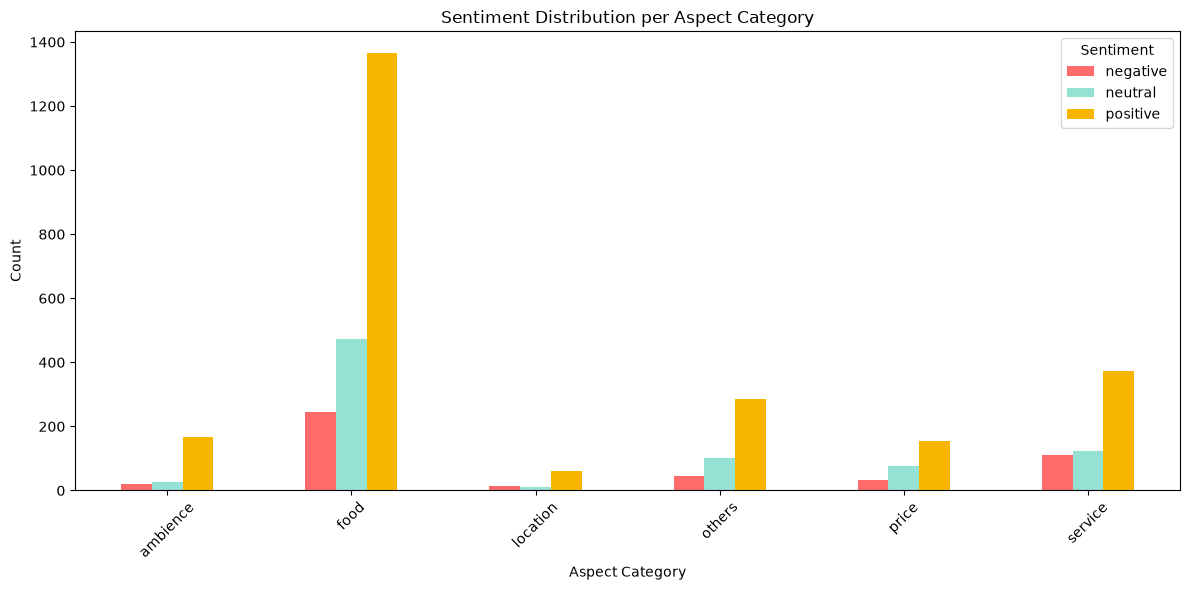

In [32]:
# Sentiment breakdown per aspect category
aspect_sentiment = train_data.groupby(
    ['aspect_category', 'predicted_sentiment']
).size().unstack(fill_value=0)

print(aspect_sentiment)

# Plot it
aspect_sentiment.plot(kind='bar', figsize=(12, 6), 
                       color=['#ff6b6b', '#95e1d3', '#f8b500'])
plt.title('Sentiment Distribution per Aspect Category')
plt.xlabel('Aspect Category')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.legend(title='Sentiment')
plt.tight_layout()
plt.show()

In [33]:
train_data.to_csv('../data/processed/train_with_sentiment.csv', index=False)

1. Used VADER SentimentIntensityAnalyzer for sentiment classification
2. VADER uses compound score: ≥0.05 positive, ≤-0.05 negative, else neutral
3. Tested on Paneer tikka example — results for Food/Service/Ambience/Price
4. Overall accuracy on test set: [fill in your number]
5. Model performs best on [positive/negative/neutral] class
6. Confusion matrix shows model struggles most with [neutral] class 
   — common limitation of lexicon-based approaches
7. Aspect-wise breakdown shows Food has highest review volume